In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import itertools as itt

import tqdm.auto as tqdm
from scipy.stats import pearsonr, spearmanr, kendalltau

from dti import data
from dti.constants import SMILES, ASSAY, ACT, TID

sns.set_context("talk")

In [26]:
data_path = Path("..") / "data" / "raw"

## kinodata

In [27]:
df = data.load_kinodata(data_path / "activities-chembl33_v0.5.csv")

In [28]:
df = df[df["activities.standard_type"] == "pIC50"]

In [39]:
ACT

'activity_value'

In [116]:
import pandas as pd
import itertools
from multiprocessing import Pool, cpu_count


def _compare_assays_within_target(args):
    target, assay_ids, df = args
    results = []

    for assay1, assay2 in itertools.combinations(assay_ids, 2):
        df1 = df[df["assay_id"] == assay1][["smiles", "activity_value"]].rename(
            columns={"activity_value": "av1"}
        )
        df2 = df[df["assay_id"] == assay2][["smiles", "activity_value"]].rename(
            columns={"activity_value": "av2"}
        )

        merged = pd.merge(df1, df2, on="smiles")
        merged = merged.sample(frac=1, random_state=42).reset_index(drop=True)

        if len(merged) < 2:
            continue  # Need at least 2 shared compounds to form pairs

        for i, j in itertools.combinations(merged.index, 2):
            smile_i = merged.loc[i, "smiles"]
            smile_j = merged.loc[j, "smiles"]

            av1_i = merged.loc[i, "av1"]
            av1_j = merged.loc[j, "av1"]
            av2_i = merged.loc[i, "av2"]
            av2_j = merged.loc[j, "av2"]

            order1 = av1_i < av1_j
            order2 = av2_i < av2_j
            consistent = order1 == order2

            results.append(
                {
                    "target": target,
                    "assay_id_1": assay1,
                    "assay_id_2": assay2,
                    "smiles_i": smile_i,
                    "smiles_j": smile_j,
                    "activity_value_1_i": av1_i,
                    "activity_value_1_j": av1_j,
                    "activity_value_2_i": av2_i,
                    "activity_value_2_j": av2_j,
                    "consistent": consistent,
                }
            )

    return results


def check_consistency_parallel(df, n_jobs=None):
    if n_jobs is None:
        n_jobs = max(1, cpu_count() - 1)

    # Drop assays with <2 compounds
    assay_counts = df.groupby("assay_id")["smiles"].nunique()
    valid_assays = assay_counts[assay_counts >= 2].index
    df = df[df["assay_id"].isin(valid_assays)]

    # Map assay_id → target (assuming 1:1)
    assay_to_target = df.groupby("assay_id")["target"].first()

    # Group assay_ids by target
    target_to_assays = {}
    for assay_id, target in assay_to_target.items():
        target_to_assays.setdefault(target, []).append(assay_id)

    # Prepare parallel arguments
    args = [
        (target, assay_ids, df[df["target"] == target])
        for target, assay_ids in target_to_assays.items()
    ]

    # Run in parallel
    with Pool(n_jobs) as pool:
        all_results = pool.map(_compare_assays_within_target, tqdm.tqdm(args))

    # Flatten results
    flat_results = list(itertools.chain.from_iterable(all_results))
    return pd.DataFrame(flat_results)

In [ ]:
result_df = check_consistency_parallel(df, n_jobs=8)

result_df.to_csv("data/kinodata_pairs.csv")

  0%|          | 0/354 [00:00<?, ?it/s]

In [110]:
result_df = pd.read_csv("data/kinodata_pairs.csv", index_col=0)

In [111]:
result_df["consistent"].mean()

np.float64(0.8036951501154734)

Text(0.5, 1.0, 'Assay 2 pairwise differences')

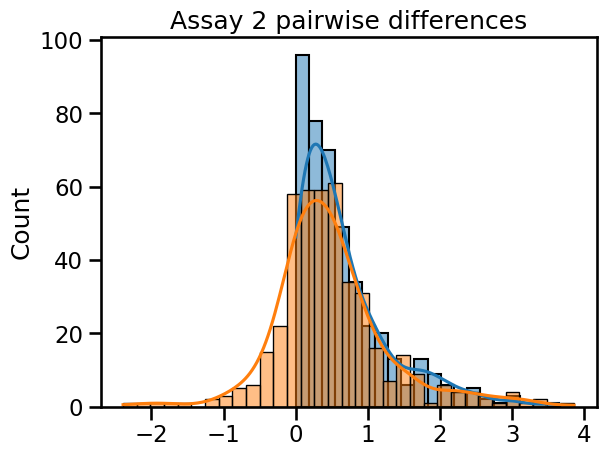

In [115]:
import seaborn as sns

# Check distributions
sns.histplot(
    result_df["activity_value_1_i"] - result_df["activity_value_1_j"], kde=True
)
plt.title("Assay 1 pairwise differences")

sns.histplot(
    result_df["activity_value_2_i"] - result_df["activity_value_2_j"], kde=True
)
plt.title("Assay 2 pairwise differences")

In [112]:
result_df["delta_1"] = result_df["activity_value_1_i"] - result_df["activity_value_1_j"]
result_df["delta_2"] = result_df["activity_value_2_i"] - result_df["activity_value_2_j"]

In [113]:
result_df["delta_1"].min()

np.float64(0.0)

<Axes: xlabel='delta_1', ylabel='delta_2'>

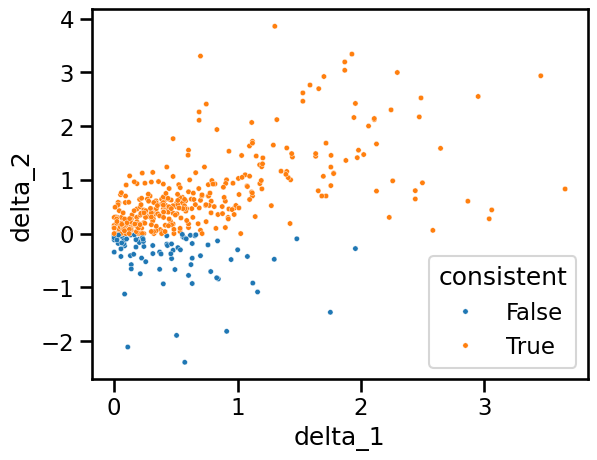

In [114]:
sns.scatterplot(result_df, x="delta_1", y="delta_2", s=15, hue="consistent")

In [5]:
xs = list()
ys = list()
for _, g in tqdm.tqdm(df.groupby([SMILES, TID])):
    if len(g) == 1:
        continue
    for x, y in itt.combinations(g[[ASSAY, ACT]].groupby(ASSAY).agg("mean")[ACT], 2):
        xs.append(x)
        xs.append(y)
        ys.append(y)
        ys.append(x)

  0%|          | 0/178345 [00:00<?, ?it/s]

In [6]:
xs = np.array(xs)
ys = np.array(ys)

In [7]:
mae = np.abs(xs - ys).mean()
pr = pearsonr(xs, ys).statistic
kt = kendalltau(xs, ys).statistic
sr = spearmanr(xs, ys).statistic
print(f"p={pr:.2f}\nMAE={mae:.2f}\nKendall's tau={kt:.2f}")

p=0.48
MAE=0.81
Kendall's tau=0.33


Text(0.5, 1.0, 'IC50 agreement (kinodata)')

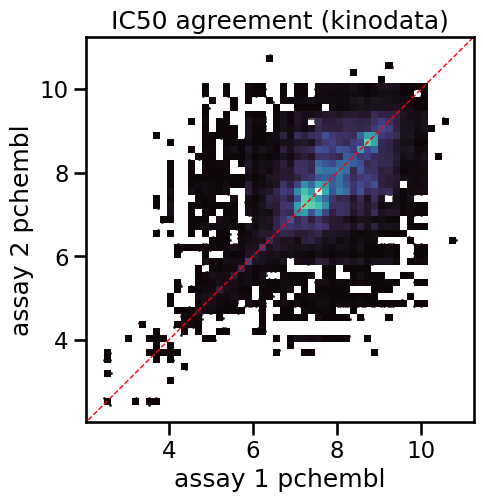

In [9]:
plt.figure(figsize=(5, 5))
# plt.scatter(xs, ys, s=5, alpha=0.3)
sns.scatterplot(x=xs, y=ys, s=5, color=".15")
sns.histplot(x=xs, y=ys, bins=50, cmap="mako")  # , pthresh=0.1
plt.xlabel("assay 1 pchembl")
plt.ylabel("assay 2 pchembl")
xl = plt.xlim()
yl = plt.ylim()
plt.plot([0, 15], [0, 15], "r--", lw=1)
plt.xlim(*xl)
plt.ylim(*yl)
plt.title("IC50 agreement (kinodata)")

## landrum

In [10]:
df = data.load_landrum(data_path / "landrum.csv")

In [11]:
xs = list()
ys = list()
for _, g in tqdm.tqdm(df.groupby([SMILES, TID])):
    if len(g) == 1:
        continue
    for x, y in itt.combinations(g[[ASSAY, ACT]].groupby(ASSAY).agg("mean")[ACT], 2):
        xs.append(x)
        xs.append(y)
        ys.append(y)
        ys.append(x)

  0%|          | 0/230879 [00:00<?, ?it/s]

In [12]:
xs = np.array(xs)
ys = np.array(ys)

In [13]:
mae = np.abs(xs - ys).mean()
pr = pearsonr(xs, ys).statistic
kt = kendalltau(xs, ys).statistic
sr = spearmanr(xs, ys).statistic
print(f"p={pr:.2f}\nMAE={mae:.2f}\nKendall's tau={kt:.2f}")

p=0.74
MAE=0.60
Kendall's tau=0.56


Text(0.5, 1.0, 'IC50 agreement (landrum)')

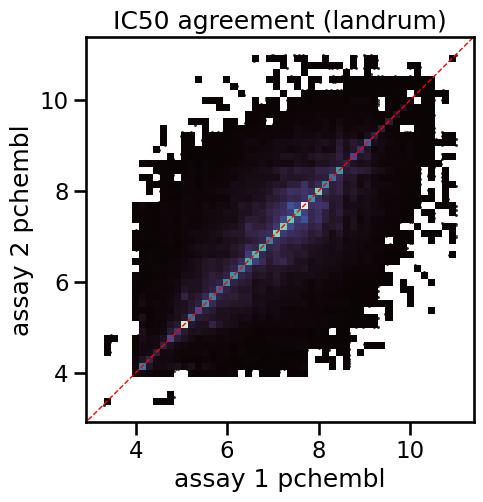

In [14]:
plt.figure(figsize=(5, 5))
# plt.scatter(xs, ys, s=5, alpha=0.3)
sns.scatterplot(x=xs, y=ys, s=5, color=".15")
sns.histplot(x=xs, y=ys, bins=50, cmap="mako")  # , pthresh=0.1
plt.xlabel("assay 1 pchembl")
plt.ylabel("assay 2 pchembl")
xl = plt.xlim()
yl = plt.ylim()
plt.plot([0, 15], [0, 15], "r--", lw=1)
plt.xlim(*xl)
plt.ylim(*yl)
plt.title("IC50 agreement (landrum)")

## omnivore

In [15]:
df = data.load_landrum(data_path / "omnivore.csv")

In [16]:
xs = list()
ys = list()
for _, g in tqdm.tqdm(df.groupby([SMILES, TID])):
    if len(g) == 1:
        continue
    for x, y in itt.combinations(g[[ASSAY, ACT]].groupby(ASSAY).agg("mean")[ACT], 2):
        xs.append(x)
        xs.append(y)
        ys.append(y)
        ys.append(x)

  0%|          | 0/699225 [00:00<?, ?it/s]

In [17]:
xs = np.array(xs)
ys = np.array(ys)

In [18]:
mae = np.abs(xs - ys).mean()
pr = pearsonr(xs, ys).statistic
kt = kendalltau(xs, ys).statistic
sr = spearmanr(xs, ys).statistic
print(f"p={pr:.2f}\nMAE={mae:.2f}\nKendall's tau={kt:.2f}")

p=0.72
MAE=0.61
Kendall's tau=0.54


Text(0.5, 1.0, 'IC50 agreement (omnivore)')

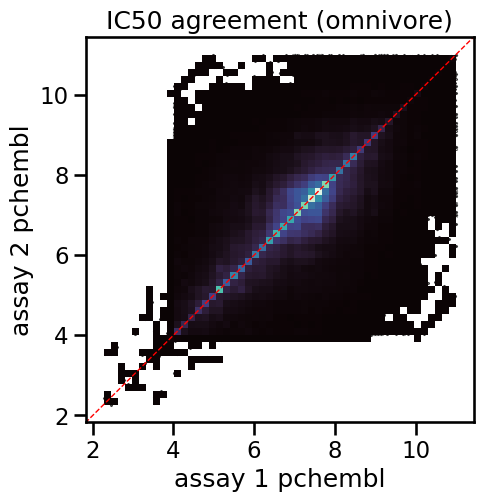

In [19]:
plt.figure(figsize=(5, 5))
# plt.scatter(xs, ys, s=5, alpha=0.3)
sns.scatterplot(x=xs, y=ys, s=5, color=".15")
sns.histplot(x=xs, y=ys, bins=50, cmap="mako")  # , pthresh=0.1
plt.xlabel("assay 1 pchembl")
plt.ylabel("assay 2 pchembl")
xl = plt.xlim()
yl = plt.ylim()
plt.plot([0, 15], [0, 15], "r--", lw=1)
plt.xlim(*xl)
plt.ylim(*yl)
plt.title("IC50 agreement (omnivore)")